# Exercise 3

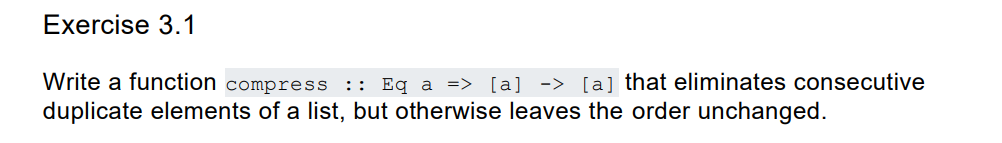

In [12]:
compress :: Eq a => [a] -> [a]
compress [] = []
compress [x] = [x]
compress [x, y]
    | x == y = [x]
    | otherwise = [x,y]
compress (x:y:xs)
    | x == y = compress(x:xs)
    | otherwise = x : compress (y:xs)

compress [1,2,2,2,5]
compress []
compress [1]
compress [1,1,1,1]
compress [1,2,3,4]

[1,2,5]

[]

[1]

[1]

[1,2,3,4]

```haskell
-- compress should eliminate consecutive duplicate elements of a list
-- For example, compress [1, 3, 1, 1, 2, 5] == [1, 3, 1, 2, 5]
-- Question: Why do we need the "Eq a" class constraint?
-- We're going to have to compare elements so we can tell which ones to drop.
-- This requires that a satisfies the Eq typeclass interface.
compress :: Eq a => [a] -> [a]
-- Empty list, nothing to do
compress [] = []
-- If you wanted to match the pattern and bind the whole thing to a
-- variable, you would do
-- compress xs@[_] = xs
compress [x] = [x]
-- We have at least two elements, great, there's something we might be
-- able to compress
compress (x:y:xs)
  | x == y    = compress (y:xs)
  | otherwise = x : compress (y:xs)

-- It's interesting to see how to write this with foldr (see also
-- exercise 5).
-- The selection function is basically the same
-- but the second argument which is now the tail of the list
-- is already transformed.
-- So if we reach the end, then we return our current entry
-- otherwise we just check if we should cons our current entry on the
-- front of the already-transformed tail.
compress' :: Eq a => [a] -> [a]
compress' = foldr pick []
  where pick x [] = [x]
        pick x (y:xs)
          | x == y    = y:xs
          | otherwise = x:y:xs
```

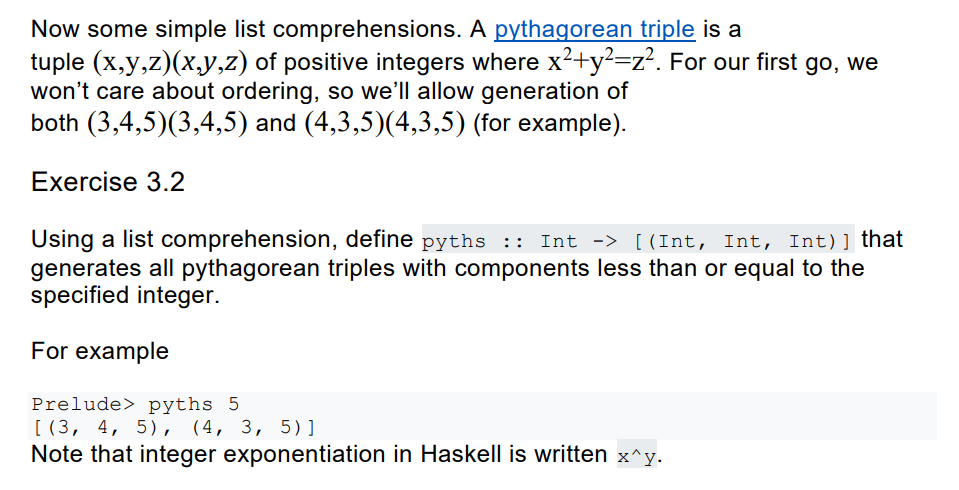

In [16]:
pyths :: Int -> [(Int, Int, Int)]
pyths n = [(x,y,z) | x <- [1..n], y <- [1..n], z <- [1..n], x^2 + y^2 == z^2]

pyths 5

[(3,4,5),(4,3,5)]

```haskell
-- A pythagorean triplet is a triple of positive integers (x, y, z)
-- such that x^2 + y^2 = z^2.
-- Define a function pyths using a list comprehension that returns all
-- pythagorean triples with components in [1..n], don't wory about
-- duplicates.
-- For example
-- pyths 5 == [(3, 4, 5), (4, 3, 5)]
-- Hint: Integer exponentiation is written x^y
pyths :: Int -> [(Int, Int, Int)]
-- We just iterate over all tuples of integers are keep those that
-- satisfy the relation we want.
pyths n = [(x, y, z) | x <- [1..n], y <- [1..n], z <- [1..n], x^2 + y^2 == z^2]
```

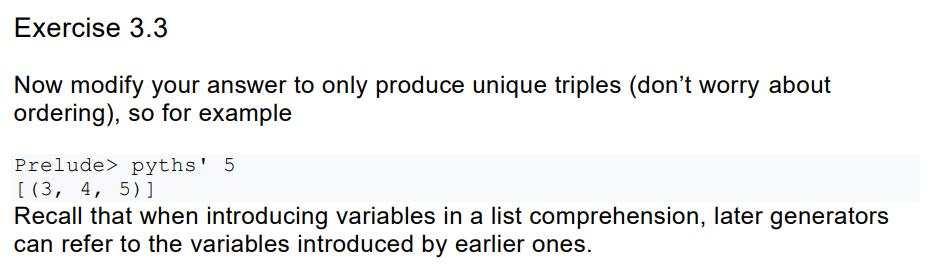

In [18]:
pyths' :: Int -> [(Int, Int, Int)]
pyths' n = [(x,y,z) | x <- [1..n], y <- [x..n], z <- [1..n], x^2 + y^2 == z^2]

pyths' 5

[(3,4,5)]

```haskell
-- Now do the same thing, but modify your solution to only produce
-- unique triples.
-- So for example
-- pyths' 5 == [(3, 4, 5)]
-- or some permutation (but there should only be one entry in the
-- list)
-- Hint: remember that in a list comprehension assignments can refer
-- to variables that are already bound.
pyths' :: Int -> [(Int, Int, Int)]
-- This time we start with z and for the later generators only count
-- up as far as the previous value.
-- Aside: this style of formatting is quite typical (the commas at the
-- beginning of the line allow us to align the generators so we can
-- see the patterns).
pyths' n = [(x, y, z)
           | z <- [1..n]
           , y <- [1..z]
           , x <- [1..y]
           , x^2 + y^2 == z^2]
```

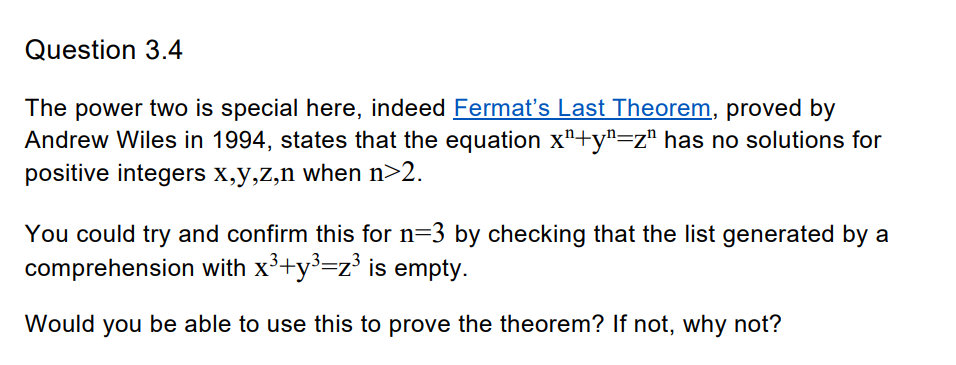

No - this would require checking every possible triplet (x,y,z). There are infinite such triplets, and therefore the program would never terminate. 

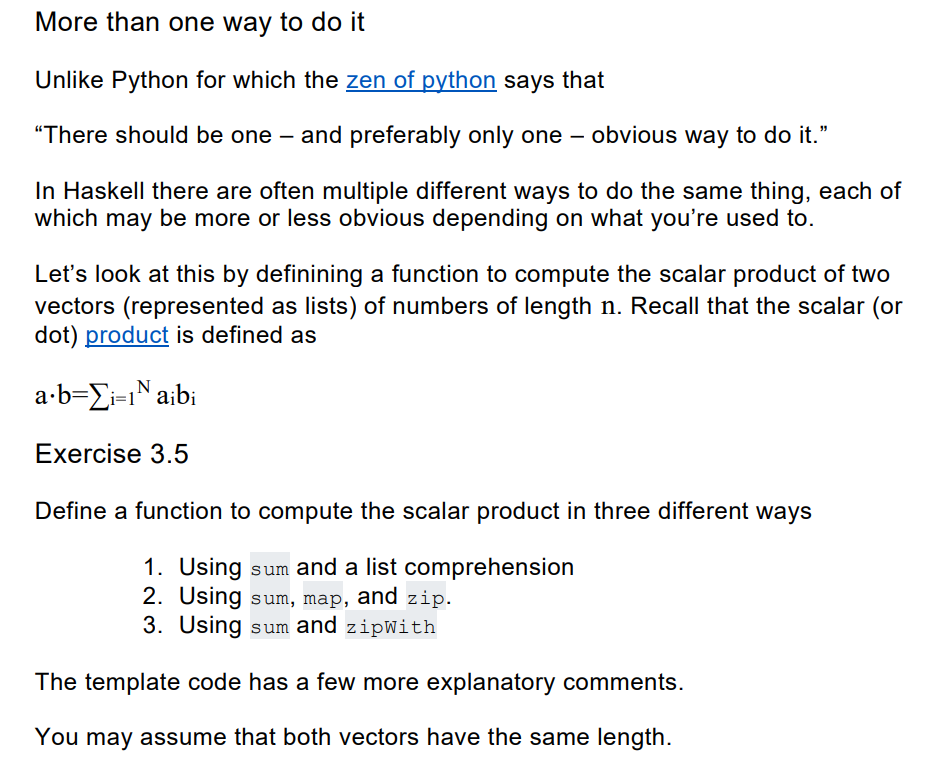

In [27]:
scalarProduct :: Num a => [a] -> [a] -> a
scalarProduct v1 v2 = sum [(v1 !! i) * (v2 !! i) | i <- [0..(len-1)]]
    where len = length v1


scalarProduct [1,2,3] [1,2,1]

8

In [30]:
scalarProduct' :: Num a => [a] -> [a] -> a
scalarProduct' a b = sum (map (\(x,y) -> x*y) (zip a b))

scalarProduct' [1,2,3] [1,2,1]

Line 2: Use zipWith
Found:
map (\ (x, y) -> x * y) (zip a b)
Why not:
zipWith (curry (\ (x, y) -> x * y)) a bLine 2: Use uncurry
Found:
\ (x, y) -> x * y
Why not:
uncurry (*)

8

In [32]:
scalarProduct'' :: Num a => [a] -> [a] -> a
scalarProduct'' a b = sum (zipWith (*) a b)

scalarProduct'' [1,2,3] [1,2,1]

8

```haskell
-- The scalar product of two vectors (lists) x, and y, of numbers of
-- length $n$ is sum_i x_i y_y.
-- Compute the scalar product using a list comprehension
scalarproduct :: Num a => [a] -> [a] -> a
-- Here's one way, really we're kind of cheating because we're zipping
-- too.
-- To be able to do this without zip we need to turn on the
-- ParallelLispComp LANGUAGE extension
scalarproduct xs ys = sum [x * y | (x, y) <- zip xs ys]
-- scalarproduct xs ys = sum [x * y | x <- xs | y <- ys]

-- Now let's do the same thing using zip, map, and sum
-- Use zip to merge the two lists into tuples, do the pointwise
-- multiplication with map and then sum up the results.
scalarproduct' :: Num a => [a] -> [a] -> a
-- zip delivers a pair (x, y) and (*) is in curried form, so we
-- uncurry it to use it in map.
scalarproduct' xs ys = sum (map (uncurry (*)) (zip xs ys))

-- Finally, we'll note that the pattern of mapping a binary function
-- over two zipped lists is captured by the library function zipWith.
-- So try doing the same thing using sum and zipWith
-- In fact, the LSP interaction in my editor underlines the map
-- definition above and suggests that I use zipWith instead
scalarproduct'' :: Num a => [a] -> [a] -> a
scalarproduct'' xs ys = sum (zipWith (*) xs ys)
```

# Exercise 4

In [33]:
-- Split a list into two (approximately) equal-length sublists
halve :: [a] -> ([a], [a])
halve = undefined

-- Merge two sorted lists into one sorted list
merge :: Ord a => [a] -> [a] -> [a]
merge = undefined

-- Sort a list using merge sort
mergeSort :: Ord a => [a] -> [a]
mergeSort = undefined


-- Now do things using a user-providing ordering function
mergeWith :: (a -> a -> Ordering) -> [a] -> [a] -> [a]
mergeWith = undefined

mergeSortWith :: (a -> a -> Ordering) -> [a] -> [a]
mergeSortWith = undefined

-- You can now get the implementation with the Ord class constraint by
-- using the builtin generic function `compare` as the comparator

mergeSort' :: Ord a => [a] -> [a]
mergeSort' = mergeSortWith compare

-- A type synonym to save on typing
type Comparator a = a -> a -> Ordering


-- Manipulation of comparisons
-- Swap the order of a comparison
invertOrdering :: Ordering -> Ordering
invertOrdering LT = GT
invertOrdering GT = LT
invertOrdering EQ = EQ

-- Implement the inverse of a comparator by using invertOrdering
invert :: Comparator a -> Comparator a
invert = undefined

sortReverse :: Ord a => [a] -> [a]
sortReverse xs = mergeSortWith (invert compare) xs

-- Manipulating comparators

-- Implement the binary function `on` which takes a `Comparator a` and a
-- function (b -> a) to produce a `Comparator b`.
on :: Comparator a -> (b -> a) -> Comparator b
on = undefined

-- Now using the invert and on functions, implement sorting a list of
-- pairs in reverse order by the length of its second elements.
sortReversedByLengthSnd :: [(a, String)] -> [(a, String)]
sortReversedByLengthSnd = undefined

Line 43: Eta reduce
Found:
sortReverse xs = mergeSortWith (invert compare) xs
Why not:
sortReverse = mergeSortWith (invert compare)

In [38]:
halve xs = splitAt m xs 
    where m = length xs `div` 2

halve [1,2,3,4]
halve [1,2,3,4,5]

([1,2],[3,4])

([1,2],[3,4,5])

In [42]:
merge xs [] = xs
merge [] xs = xs
merge (x:xs) (y:ys) 
    | x <= y = x: merge xs (y:ys)
    | otherwise = y: merge (x:xs) ys

merge [1,2,3] [0,4,6]

[0,1,2,3,4,6]

In [46]:
mergeSort [] = []
mergeSort [x] = [x]
mergeSort xs = merge (mergeSort left) (mergeSort right)
    where (left, right) = halve xs

In [47]:
mergeSort [4,1,3,6,8]

[1,3,4,6,8]

```haskell
-- Split a list into two (approximately) equal-length sublists
-- We can use splitAt and find the midpoint by using div to compute
-- the integer division of the lists length.
halve :: [a] -> ([a], [a])
halve xs = splitAt (length xs `div` 2) xs

-- Merge two sorted lists into one sorted list
merge :: Ord a => [a] -> [a] -> [a]
merge [] ys = ys
merge xs [] = xs
merge (x:xs) (y:ys)
  | x < y     = x : merge xs (y:ys)
  | otherwise = y : merge (x:xs) ys

-- Sort a list using merge sort
mergeSort :: Ord a => [a] -> [a]
-- empty lists are sorted
mergeSort [] = []
-- As are singletons (I forget this case first time)
mergeSort [x] = [x]
-- otherwise merge two sorted sublists, which we obtain by splitting
-- the input in halves and recursing on those sublists.
mergeSort xs = merge ys zs
  where (left, right) = halve xs
        ys = mergeSort left
        zs = mergeSort right
```

```haskell
-- Now do things using a user-providing ordering function
-- If we check :info Ordering we see that it has three values LT, EQ,
-- and GT.
mergeWith :: (a -> a -> Ordering) -> [a] -> [a] -> [a]
-- We can ignore the ordering function for the empty list cases
mergeWith _ [] ys = ys
mergeWith _ xs [] = xs
-- Now we need it
mergeWith ord (x:xs) (y:ys)
  | ord x y == LT = x : mergeWith ord xs (y:ys) -- x < y, so comes first
  | otherwise     = y : mergeWith ord (x:xs) ys -- otherwise y is first.

mergeSortWith :: (a -> a -> Ordering) -> [a] -> [a]
mergeSortWith _ [] = []
mergeSortWith _ [x] = [x]
-- otherwise merge two sorted sublists, which we obtain by splitting
-- the input in halves and recursing on those sublists.
-- So this is the same as before but we push the extra ordering
-- function through everywhere
mergeSortWith ord xs = mergeWith ord ys zs
  where (left, right) = halve xs
        ys = mergeSortWith ord left
        zs = mergeSortWith ord right

-- You can now get the implementation with the Ord class constraint by
-- using the builtin generic function `compare` as the comparator
mergeSort' :: Ord a => [a] -> [a]
mergeSort' = mergeSortWith compare

-- A type synonym to save on typing
type Comparator a = a -> a -> Ordering


-- Manipulation of comparisons
-- Swap the order of a comparison
invertOrdering :: Ordering -> Ordering
invertOrdering LT = GT
invertOrdering GT = LT
invertOrdering EQ = EQ

-- Implement the inverse of a comparator by using invertOrdering
invert :: Comparator a -> Comparator a
-- Using invertOrdering we invert the result of calling and ordering function
invert ord = \x y -> invertOrdering (ord x y)

-- We can actually simplify this to
invert' :: Comparator a -> Comparator a
-- This looks strange because the type signature looks like we only
-- take one argument (but remember the type synonym we introduced
-- above)
invert' ord x y = invertOrdering (ord x y)

-- We can actually do this without invertOrdering at all
invert'' :: Comparator a -> Comparator a
invert'' ord = \x y -> ord y x
-- and, remembering the definition of flip
invert''' :: Comparator a -> Comparator a
invert''' = flip

-- Sorting in reverse is now a case of sorting with an inverted comparator.
sortReverse :: Ord a => [a] -> [a]
sortReverse = mergeSortWith (invert compare)


-- Manipulating comparators

-- Implement the binary function `on` which takes a `Comparator a` and a
-- function (b -> a) to produce a `Comparator b`.
on :: Comparator a -> (b -> a) -> Comparator b
-- We need to return a function which calls our comparator on the
-- transformed arguments
-- Here we use a lambda and call f x and f y to deliver values of type
-- a which our comparator understands
on cmp f = \x y -> cmp (f x) (f y)

-- Now using the invert and on functions, implement sorting a list of
-- pairs in reverse order by the length of its second elements.
sortReversedByLengthSnd :: [(a, String)] -> [(a, String)]
-- For each entry, we need to deliver the length of the second entry
-- Available via f = (length . snd)
-- We (compare `on` f) to implement the comparison, and finally invert
-- that comparator
sortReversedByLengthSnd = mergeSortWith (invert (compare `on` (length . snd)))
```